In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys, os, math, scipy

sys.path.insert(1, '../')

from VI_solvers.rad_vi import RadVI
from VI_solvers.laplace_approx import laplace_from_potential
from VI_solvers.gaussian_fbvi import Gaussian_FBVI

from utils.plotting import plot_2dim_scatter
from utils.neals_funnel_helpers import f_global_z2, f_local_squared, f_tail_2, f_tail_3, make_results_table
from utils.elliptical_distributions import NealsFunnel
from utils.importance_sampling import importance_sampling_GVI, importance_sampling_radvi

In [2]:
plt.rcParams.update({"text.usetex": True})
plt.rcParams.update({"font.family": "serif", "font.serif": "Computer Modern"})
np.random.seed(2)

if not os.path.exists('plots/neals_funnel'):
    os.makedirs('plots/neals_funnel')

In [3]:
### Define target distribution
dim = 50

neal_sigma = 2

target_distribution = NealsFunnel(dim,sigma=neal_sigma)
V_nealsfunnel       = lambda x: target_distribution.potential(x)
gradV_nealsfunnel   = lambda x: target_distribution.grad_potential(x)
hessV_nealsfunnel   = lambda x: target_distribution.hess_potential(x)

In [4]:
### Define radVI parameters
truncation = np.sqrt(np.log(dim))
alpha = 0.01
if dim == 10:
    mesh = 1/(dim**(1/2))
elif dim == 25: 
    mesh = 1/(dim**(1/4))
elif dim == 50:
    mesh = 1/(dim**(1/6))
elif dim == 100:
    mesh = 1/(dim**(1/8))
J = int(2 * truncation / mesh) + 1

### Define optimizer parameters
if dim == 10:
    learning_rate = 1e-2
    n_iterations   = 5000 * 6
elif dim == 25: 
    learning_rate = 7e-3
    n_iterations   = 5000 * 6
elif dim == 50:
    learning_rate = 2e-2
    n_iterations   = 5000 * 8
elif dim == 100:
    learning_rate = 7e-3
    n_iterations   = 5000 * 8
n_samples_sgd  = 100
n_samples_mc   = 10**4
n_samples_plot = 20000

In [5]:
### Fit Gaussian VI 
gaussian_fbvi = Gaussian_FBVI(learning_rate=learning_rate,
                              dim=dim,
                              grad_V=gradV_nealsfunnel,
                              hess_V=hessV_nealsfunnel,
                              mean=np.zeros((dim, 1)),
                              covariance=np.eye(dim))

gaussian_fbvi.fit(num_iterations=n_iterations, sample_size=n_samples_sgd, print_freq=5000)

mean_fbvi_approx_nealsfunnel = gaussian_fbvi.mean
cov_fbvi_approx_nealsfunnel  = gaussian_fbvi.sigma 

### Initialize and fit radVI model with Gaussian FBVI approximation of mean and covariance
RadVI_nealsfunnel_fbvi = RadVI(truncation=truncation, 
                               mesh=mesh, 
                               dim=dim, 
                               alpha=alpha, 
                               isotropic=False,
                               V=V_nealsfunnel,
                               grad_V=gradV_nealsfunnel, 
                               mean=mean_fbvi_approx_nealsfunnel, 
                               covariance=cov_fbvi_approx_nealsfunnel,
                               N_mc=n_samples_mc)

RadVI_nealsfunnel_fbvi.fit(learning_rate=learning_rate*2,
                           num_iterations=n_iterations, 
                           sample_size=n_samples_sgd,
                           print_freq=5000)


--------------------------------------------------
       Fitting Gaussian FBVI Approximation 
--------------------------------------------------
Optimizer settings:
• Learning rate   : 0.02
• Iterations      : 40000
• Sample size     : 100
--------------------------------------------------



/Users/lucaghafourpour/Documents/ETH MSc/radVI/examples/../utils/elliptical_distributions.py:667: ComplexWarning: Casting complex values to real discards the imaginary part
  H[0, 0, :] = 1.0 / (self.sigma**2) + 0.5 * e_z * S         # d^2 V / dz^2
/Users/lucaghafourpour/Documents/ETH MSc/radVI/examples/../utils/elliptical_distributions.py:669: ComplexWarning: Casting complex values to real discards the imaginary part
  H[0, 1:, :] = -e_z[None, :] * xs                           # cross terms d^2 V / dz dx_i
/Users/lucaghafourpour/Documents/ETH MSc/radVI/examples/../utils/elliptical_distributions.py:670: ComplexWarning: Casting complex values to real discards the imaginary part
  H[1:, 0, :] = -e_z[None, :] * xs
/Users/lucaghafourpour/Documents/ETH MSc/radVI/examples/../utils/elliptical_distributions.py:673: ComplexWarning: Casting complex values to real discards the imaginary part
  H[1 + i, 1 + i, :] = e_z                               # diagonal d^2 V / dx_i^2


Iteration 5000 of 40000
Iteration 10000 of 40000
Iteration 15000 of 40000
Iteration 20000 of 40000
Iteration 25000 of 40000
Iteration 30000 of 40000
Iteration 35000 of 40000
Iteration 40000 of 40000
Completed fitting Gaussian FBVI approximation.


--------------------------------------------------
       Fitting radVI Approximation 
--------------------------------------------------
• Mesh            : 0.5210007309586914
• Truncation      : 1.977883466088977
• Alpha           : 0.01
• Num. basis (J)  : 8
• Whitening       : Yes

Optimizer settings:
• Learning rate   : 0.04
• Iterations      : 40000
• Sample size     : 100
--------------------------------------------------

Iteration 5000 of 40000
Iteration 10000 of 40000
Iteration 15000 of 40000
Iteration 20000 of 40000
Iteration 25000 of 40000
Iteration 30000 of 40000
Iteration 35000 of 40000
Iteration 40000 of 40000
Completed fitting radVI approximation.



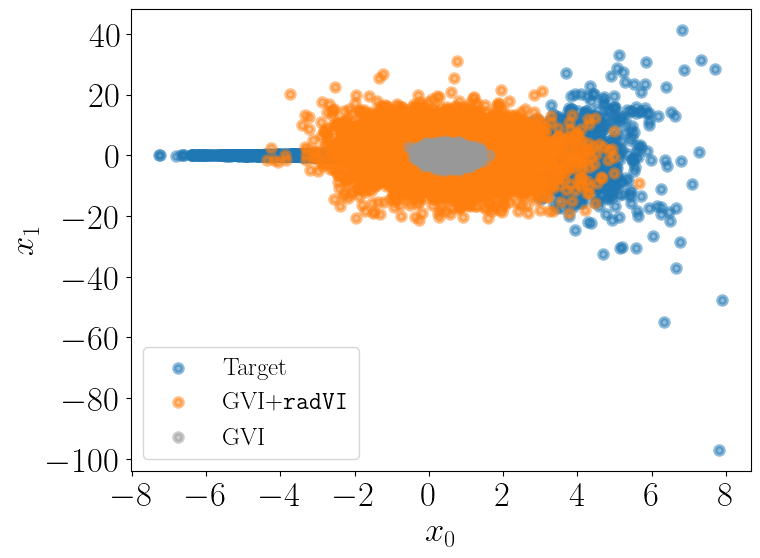

In [6]:
### Generate Gaussian VI approximation samples
fbvi_data = np.random.multivariate_normal(mean=mean_fbvi_approx_nealsfunnel.flatten(), cov=cov_fbvi_approx_nealsfunnel, size=n_samples_plot).T

### Generate pushforward data of radVI whitened using Gaussian VI approximation
source_data      = np.random.randn(dim, n_samples_plot)
pushforward_fbvi = RadVI_nealsfunnel_fbvi.push_forward(source_data)

### Generate true target density samples
target_data = target_distribution.sample(n_samples_plot)

### Radial diagnostics
r_pushforward_fbvi = np.linalg.norm(pushforward_fbvi, axis=0)
r_target           = np.linalg.norm(target_data, axis=0)
r_fbvi             = np.linalg.norm(fbvi_data, axis=0)

plot_2dim_scatter([{"data": target_data, "label": "Target"},
                   {"data": pushforward_fbvi, "label": r"GVI$+\texttt{radVI}$"},
                   {"data": fbvi_data, "label": r"GVI", "color": "#999999"}],
                   save_path=f'plots/neals_funnel/funnel_scatter_dim{dim}.pdf')

## Compute Statistics

We would like to compute the following statistics of the global variable ($z$) and the local variable ($x_1$) of the Neals' funnel distribution:
- $\mathbb{E}[z^2]$
- $\mathbb{E}[x_1^2]$
- $\mathbb{P}(z>2)$
- $\mathbb{P}(z>3)$

and their accompanying standard errors, for both the Gaussian VI and radVI approximations. We'll generate 2000 samples using both methods, and average them over 1000 trials.

In [7]:
logp_funnel = lambda x: -target_distribution.potential(x) # minus since .potential() returns the negative log-density

n_samples = 2000
n_trials = 1000

In [8]:
## Compute the ground truth statistics
global_var_true      = neal_sigma**2
local_var_true       = np.exp(neal_sigma)
tail_prob_2_true     = 1 - (0.5 * (1.0 + math.erf(2 / math.sqrt(2.0))))/2
tail_prob_3_true     = 1 - (0.5 * (1.0 + math.erf(3 / math.sqrt(2.0))))/2

In [9]:
### Compute estimates of E[z^2] from Gaussian VI and radVI approximations using importance sampling
global_var_GVI_list  = []
global_var_radVI_list = []

for i in range(n_trials):

    est_GVI, ess_GVI = importance_sampling_GVI(potential=logp_funnel,
                                               m_hat=mean_fbvi_approx_nealsfunnel.flatten(),
                                               cov_hat=cov_fbvi_approx_nealsfunnel,
                                               f=f_global_z2,
                                               n_samples=n_samples)

    global_var_GVI_list.append(est_GVI) 

    est_radVI, ess_radVI = importance_sampling_radvi(potential=logp_funnel,
                                                     radvi_obj=RadVI_nealsfunnel_fbvi,
                                                     f=f_global_z2,
                                                     dim=dim,
                                                     n_samples=n_samples)

    global_var_radVI_list.append(est_radVI)

global_var_GVI_avg = np.mean(global_var_GVI_list)
global_var_GVI_se = np.std(global_var_GVI_list) / np.sqrt(n_trials)

global_var_radVI_avg = np.mean(global_var_radVI_list)
global_var_radVI_se = np.std(global_var_radVI_list) / np.sqrt(n_trials)

In [10]:
### Compute estimates of E[x_1^2] from Gaussian VI and radVI approximations using importance sampling
local_var_GVI_list = []
local_var_radVI_list = []

for i in range(n_trials):

    est_GVI, ess_GVI = importance_sampling_GVI(potential=logp_funnel,
                                               m_hat=mean_fbvi_approx_nealsfunnel.flatten(),
                                               cov_hat=cov_fbvi_approx_nealsfunnel,
                                               f=f_local_squared,
                                               n_samples=n_samples)

    local_var_GVI_list.append(est_GVI)

    est_radVI, ess_radVI = importance_sampling_radvi(potential = logp_funnel,
                                                     radvi_obj=RadVI_nealsfunnel_fbvi,
                                                     f=f_local_squared,
                                                     dim=dim,
                                                     n_samples=n_samples)

    local_var_radVI_list.append(est_radVI)

local_var_GVI_avg = np.mean(local_var_GVI_list)
local_var_GVI_se = np.std(local_var_GVI_list) / np.sqrt(n_trials)

local_var_radVI_avg = np.mean(local_var_radVI_list)
local_var_radVI_se = np.std(local_var_radVI_list) / np.sqrt(n_trials)

In [11]:
### Compute estimate of P(z>2) from Gaussian VI and radVI approximations using importance sampling
tail_prob_2_GVI_list = []
tail_prob_2_radVI_list = []

for i in range(n_trials):

    est_GVI, ess_GVI = importance_sampling_GVI(potential=logp_funnel,
                                               m_hat=mean_fbvi_approx_nealsfunnel.flatten(),
                                               cov_hat=cov_fbvi_approx_nealsfunnel,
                                               f=f_tail_2,
                                               n_samples=n_samples)

    tail_prob_2_GVI_list.append(est_GVI)

    est_radVI, ess_radVI = importance_sampling_radvi(potential=logp_funnel,
                                                     radvi_obj=RadVI_nealsfunnel_fbvi,
                                                     f=f_tail_2,
                                                     dim=dim,
                                                     n_samples=n_samples)

    tail_prob_2_radVI_list.append(est_radVI)

tail_prob_2_GVI_avg = np.mean(tail_prob_2_GVI_list)
tail_prob_2_GVI_se = np.std(tail_prob_2_GVI_list) / np.sqrt(n_trials)

tail_prob_2_radVI_avg = np.mean(tail_prob_2_radVI_list)
tail_prob_2_radVI_se = np.std(tail_prob_2_radVI_list) / np.sqrt(n_trials)

In [12]:
### Compute estimate of P(z>3) from Gaussian VI and radVI approximations using importance sampling
tail_prob_3_GVI_list = []
tail_prob_3_radVI_list = []

for i in range(n_trials):

    est_GVI, ess_GVI = importance_sampling_GVI(potential=logp_funnel,
                                               m_hat=mean_fbvi_approx_nealsfunnel.flatten(),
                                               cov_hat=cov_fbvi_approx_nealsfunnel,
                                               f=f_tail_3,
                                               n_samples=n_samples)

    tail_prob_3_GVI_list.append(est_GVI)

    est_radVI, ess_radVI = importance_sampling_radvi(potential=logp_funnel,
                                                     radvi_obj=RadVI_nealsfunnel_fbvi,
                                                     f=f_tail_3,
                                                     dim=dim,
                                                     n_samples=n_samples)

    tail_prob_3_radVI_list.append(est_radVI)

tail_prob_3_GVI_avg = np.mean(tail_prob_3_GVI_list)
tail_prob_3_GVI_se = np.std(tail_prob_3_GVI_list) / np.sqrt(n_trials)

tail_prob_3_radVI_avg = np.mean(tail_prob_3_radVI_list)
tail_prob_3_radVI_se = np.std(tail_prob_3_radVI_list) / np.sqrt(n_trials)

In [13]:
metrics = [("E[z^2]", 2),
           ("E[x_1^2]", 2),
           ("P(z>2)", 3),
           ("P(z>3)", 3)]

results = {
    "Ground Truth": {
        "E[z^2]": (global_var_true, None),
        "E[x_1^2]": (local_var_true, None),
        "P(z>2)": (tail_prob_2_true, None),
        "P(z>3)": (tail_prob_3_true, None),
    },
    "GVI": {
        "E[z^2]": (global_var_GVI_avg, global_var_GVI_se),
        "E[x_1^2]": (local_var_GVI_avg, local_var_GVI_se),
        "P(z>2)": (tail_prob_2_GVI_avg, tail_prob_2_GVI_se),
        "P(z>3)": (tail_prob_3_GVI_avg, tail_prob_3_GVI_se),
    },
    "GVI+radVI": {
        "E[z^2]": (global_var_radVI_avg, global_var_radVI_se),
        "E[x_1^2]": (local_var_radVI_avg, local_var_radVI_se),
        "P(z>2)": (tail_prob_2_radVI_avg, tail_prob_2_radVI_se),
        "P(z>3)": (tail_prob_3_radVI_avg, tail_prob_3_radVI_se),
    },
}

make_results_table(dim, metrics, results)

| Method (d=50) |           E[z^2] |         E[x_1^2] |           P(z>2) |           P(z>3) |
| ------------- | ---------------- | ---------------- | ---------------- | ---------------- |
| Ground Truth  |            4.000 |            7.389 |            0.511 |            0.501 |
| GVI           | 0.328 ± 4.57e-03 | 1.612 ± 1.79e-02 |            0 ± 0 |            0 ± 0 |
| GVI+radVI     | 2.509 ± 4.49e-02 | 6.479 ± 2.16e-01 | 0.185 ± 5.10e-03 | 0.087 ± 4.01e-03 |
